In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import json
import re
import time
import datetime
import random
import gc
import pathlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
from wordcloud import WordCloud
from tqdm import tqdm
import nltk
from nltk.corpus import stopwords

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    classification_report, f1_score, accuracy_score, roc_auc_score,
    confusion_matrix, ConfusionMatrixDisplay
)

import tensorflow as tf
import xgboost as xgb
import transformers
import torch
import torch.nn as nn
from torch.optim import AdamW
from torch.utils.data import DataLoader, RandomSampler, SequentialSampler, TensorDataset
from transformers import BertTokenizer, BertForSequenceClassification, get_linear_schedule_with_warmup
from sentence_transformers import SentenceTransformer

try:
    sw = stopwords.words("english")
except:
    nltk.download("stopwords")
    sw = stopwords.words("english")

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
tf.random.set_seed(SEED)
random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DATA_DIR = pathlib.Path("/content/drive/MyDrive/raw")
REPORTS_DIR = pathlib.Path("../reports")
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

CLASS_NAMES = ["non-toxic", "toxic", "severe_toxic"]
N_CLASSES = 3

print("Konfiguracja zakończona")

Konfiguracja zakończona


## 1. Eksploracyjna analiza danych

In [ ]:
df_raw = pd.read_csv(DATA_DIR / "train.csv")
print(f"Rozmiar surowych danych: {df_raw.shape}")
df_raw.head()

Rozmiar surowych danych: (159571, 8)


,id,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate
0,0000997932d777bf,Explanation\nWhy the edits made under my usern...,0,0,0,0,0,0
1,000103f0d9cfb60f,D'aww! He matches this background colour I'm s...,0,0,0,0,0,0
2,000113f07ec002fd,"Hey man, I'm really not trying to edit war. It...",0,0,0,0,0,0
3,0001b41b1c6bb37e,"""\nMore\nI can't make any real suggestions on ...",0,0,0,0,0,0
4,0001d958c54c6e35,"You, sir, are my hero. Any chance you remember...",0,0,0,0,0,0


In [ ]:
labels = ["toxic", "severe_toxic", "obscene", "threat", "insult", "identity_hate"]

print("Rozkład etykiet w surowych danych:")
for label in labels:
    count = df_raw[label].sum()
    pct = df_raw[label].mean() * 100
    print(f"  {label}: {count} ({pct:.1f}%)")

df_raw["is_toxic"] = df_raw[labels].max(axis=1)
toxic_count = df_raw["is_toxic"].sum()
print(f"\nŁącznie komentarzy toksycznych: {toxic_count} ({toxic_count/len(df_raw)*100:.1f}%)")

Rozkład etykiet w surowych danych:
  toxic: 15294 (9.6%)
  severe_toxic: 1595 (1.0%)
  obscene: 8449 (5.3%)
  threat: 478 (0.3%)
  insult: 7877 (4.9%)
  identity_hate: 1405 (0.9%)

Łącznie komentarzy toksycznych: 16225 (10.2%)


In [ ]:
print("Przykładowe komentarze toksyczne:")
toxic_samples = df_raw[df_raw["is_toxic"] == 1]["comment_text"].sample(3, random_state=SEED)
for i, text in enumerate(toxic_samples, 1):
    print(f"{i}. {text[:100]}...")

print("\nPrzykładowe komentarze nietoksyczne:")
nontoxic_samples = df_raw[df_raw["is_toxic"] == 0]["comment_text"].sample(3, random_state=SEED)
for i, text in enumerate(nontoxic_samples, 1):
    print(f"{i}. {text[:100]}...")

Przykładowe komentarze toksyczne:
1. "
I was talking about them running any check they want on ME to disprove your claims.  I didn't know...
2. White Trash
Fuck off you white piece of trash. Fucking wiggers. Go and fuck a Jew, Jew raper....
3. eat shit get rid of goofs you queers....

Przykładowe komentarze nietoksyczne:
1. "

Oh, don't worry about me, Sandstein. I'm of no strong opinion as to what is ""well."" Editing Wik...
2. Are you trying to dispute that fact?...
3. SWOT analysis 

This source – Align Technology, Inc. SWOT Analysis. (2013). 1-8. – is used 11 times,...


Statystyki długości komentarzy:
count    159571.000000
mean        394.073221
std         590.720282
min           6.000000
25%          96.000000
50%         205.000000
75%         435.000000
max        5000.000000
Name: text_length, dtype: float64


/tmp/ipython-input-3470122557.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax2.boxplot([df_raw[df_raw["is_toxic"]==0]["text_length"],


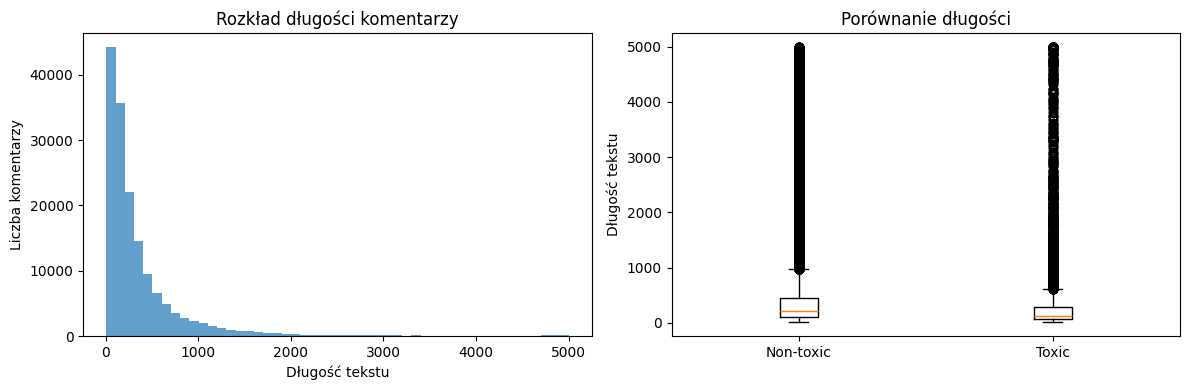

In [ ]:
df_raw["text_length"] = df_raw["comment_text"].str.len()

print("Statystyki długości komentarzy:")
print(df_raw["text_length"].describe())

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.hist(df_raw["text_length"], bins=50, alpha=0.7)
ax1.set_title("Rozkład długości komentarzy")
ax1.set_xlabel("Długość tekstu")
ax1.set_ylabel("Liczba komentarzy")

ax2.boxplot([df_raw[df_raw["is_toxic"]==0]["text_length"],
             df_raw[df_raw["is_toxic"]==1]["text_length"]],
            labels=["Non-toxic", "Toxic"])
ax2.set_title("Porównanie długości")
ax2.set_ylabel("Długość tekstu")

plt.tight_layout()
plt.show()

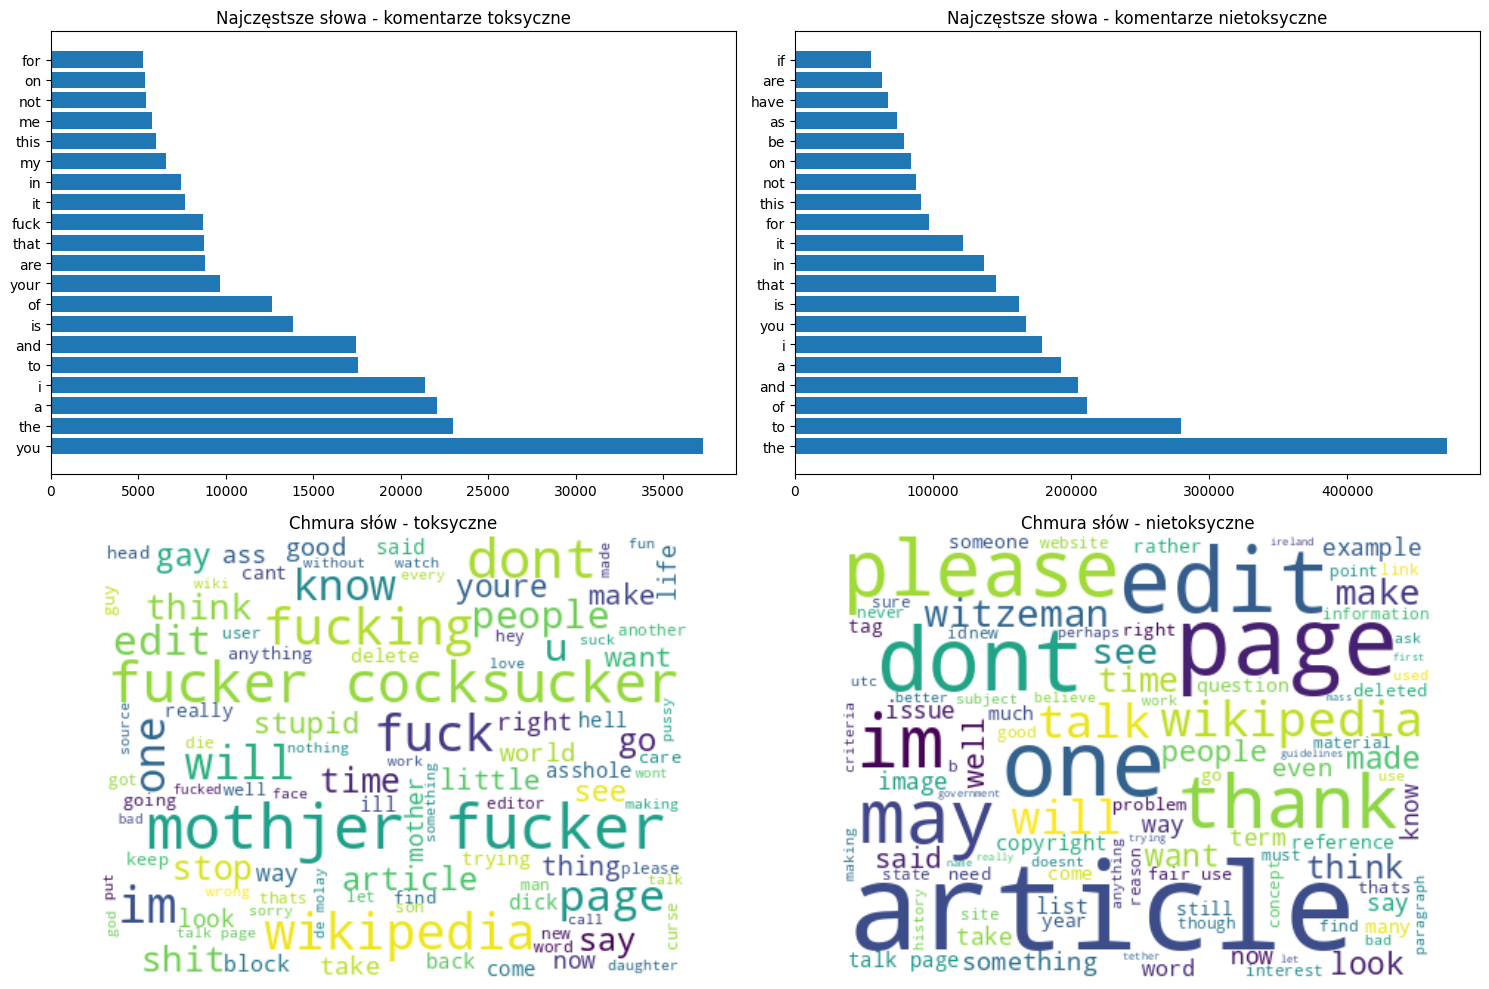

In [ ]:
def clean_text(text):
    text = re.sub(r"[^a-zA-Z\s]", "", text.lower())
    return text

toxic_texts = df_raw[df_raw["is_toxic"] == 1]["comment_text"].apply(clean_text)
nontoxic_texts = df_raw[df_raw["is_toxic"] == 0]["comment_text"].apply(clean_text)

toxic_words = " ".join(toxic_texts).split()
nontoxic_words = " ".join(nontoxic_texts).split()

toxic_freq = Counter(toxic_words).most_common(20)
nontoxic_freq = Counter(nontoxic_words).most_common(20)

fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 10))

words, counts = zip(*toxic_freq)
ax1.barh(words, counts)
ax1.set_title("Najczęstsze słowa - komentarze toksyczne")

words, counts = zip(*nontoxic_freq)
ax2.barh(words, counts)
ax2.set_title("Najczęstsze słowa - komentarze nietoksyczne")

toxic_text = " ".join(toxic_words[:10000])
wordcloud_toxic = WordCloud(width=400, height=300, background_color="white",
                           max_words=100).generate(toxic_text)
ax3.imshow(wordcloud_toxic, interpolation="bilinear")
ax3.axis("off")
ax3.set_title("Chmura słów - toksyczne")

nontoxic_text = " ".join(nontoxic_words[:10000])
wordcloud_nontoxic = WordCloud(width=400, height=300, background_color="white",
                              max_words=100).generate(nontoxic_text)
ax4.imshow(wordcloud_nontoxic, interpolation="bilinear")
ax4.axis("off")
ax4.set_title("Chmura słów - nietoksyczne")

plt.tight_layout()
plt.show()

## 2. Przygotowanie danych i podział zbioru

In [ ]:
df_all = pd.read_csv(DATA_DIR / "train.csv").dropna().drop_duplicates()

severe_labels = ["severe_toxic", "threat", "identity_hate"]
toxic_labels = ["toxic", "obscene", "insult"]
all_labels = severe_labels + toxic_labels

df_all["toxic_level"] = 0
df_all.loc[df_all[toxic_labels].max(axis=1) > 0, "toxic_level"] = 1
df_all.loc[df_all[severe_labels].max(axis=1) > 0, "toxic_level"] = 2
df_all = df_all.drop(["id"] + all_labels, axis=1)

print(f"Po przetworzeniu: {df_all.shape}")
print("Rozkład klas:")
print(df_all["toxic_level"].value_counts().sort_index())

Po przetworzeniu: (159571, 2)
Rozkład klas:
toxic_level
0    143346
1     16225
Name: count, dtype: int64


In [ ]:
def preprocess_text(text):
    text = re.sub(r'https?://\S+', "", text)
    text = text.lower()
    text = re.sub(r"'", "", text)
    text = re.sub(r"[^a-z]+", " ", text)
    words = [w for w in text.split() if w not in sw][:1024]
    return " ".join(words).strip()

df_all["comment_text"] = df_all["comment_text"].apply(preprocess_text)
print("Tekst wyczyszczony")

In [ ]:
df_train_full, df_test = train_test_split(df_all, test_size=5000, stratify=df_all["toxic_level"], random_state=SEED)
df_train_rest, df_val = train_test_split(df_train_full, test_size=2000, stratify=df_train_full["toxic_level"], random_state=SEED)

df_class_0 = df_train_rest[df_train_rest["toxic_level"] == 0]
df_class_1 = df_train_rest[df_train_rest["toxic_level"] == 1]
df_class_2 = df_train_rest[df_train_rest["toxic_level"] == 2]

n_samples_per_class = 7000

df_c0_sample = df_class_0.sample(n=n_samples_per_class, random_state=SEED)
df_c1_sample = df_class_1.sample(n=n_samples_per_class, replace=(len(df_class_1) < n_samples_per_class), random_state=SEED)
df_c2_sample = df_class_2.sample(n=n_samples_per_class, replace=(len(df_class_2) < n_samples_per_class), random_state=SEED)

df_train = pd.concat([df_c0_sample, df_c1_sample, df_c2_sample]).sample(frac=1, random_state=SEED).reset_index(drop=True)

df_train.to_csv(DATA_DIR / "df_train.csv", index=False)
df_val.to_csv(DATA_DIR / "df_val.csv", index=False)
df_test.to_csv(DATA_DIR / "df_test.csv", index=False)

print(f"Train (balanced): {len(df_train)}, Val: {len(df_val)}, Test: {len(df_test)}")
print("\nRozkład klas w train:")
print(df_train["toxic_level"].value_counts().sort_index())
print("\nRozkład klas w val:")
print(df_val["toxic_level"].value_counts().sort_index())
print("\nRozkład klas w test:")
print(df_test["toxic_level"].value_counts().sort_index())

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


Tekst wyczyszczony


## 3. Przygotowanie próbki testowej

In [ ]:
df_test_sample = df_test.copy()
df_test_sample = df_test_sample.reset_index(drop=True)
df_test_sample['original_idx'] = df_test_sample.index

df_test_sample.to_csv(DATA_DIR / "df_test_sample.csv", index=False)

sample_indices = df_test_sample.index.tolist()
with open(DATA_DIR / "sample_indices.txt", "w") as f:
    f.write(str(sample_indices))

print(f"Zbiór testowy: {len(df_test_sample)} próbek")

Zbiór testowy: 5000 próbek


## 4. Modele

In [ ]:
df_train = pd.read_csv(DATA_DIR / "df_train.csv")
df_val = pd.read_csv(DATA_DIR / "df_val.csv")
df_test_sample = pd.read_csv(DATA_DIR / "df_test_sample.csv")

X_train = df_train['comment_text'].fillna('')
y_train = df_train['toxic_level'].values

X_val = df_val['comment_text'].fillna('')
y_val = df_val['toxic_level'].values

X_test = df_test_sample['comment_text'].fillna('')
y_test = df_test_sample['toxic_level'].values

print(f"Dane przygotowane: train={len(X_train)}, val={len(X_val)}, test={len(X_test)}")

Dane przygotowane: train=20000, val=2000, test=5000


### 4.1. Baseline: TF-IDF + Logistic Regression

In [ ]:
tfidf = TfidfVectorizer(
    lowercase=True,
    strip_accents="unicode",
    ngram_range=(1, 2),
    min_df=2,
    max_features=200_000,
)

clf_baseline = LogisticRegression(
    solver="lbfgs",
    C=2.0,
    max_iter=1000,
    random_state=SEED,
)

pipe_baseline = Pipeline([("tfidf", tfidf), ("clf", clf_baseline)])
pipe_baseline.fit(X_train, y_train)

Pipeline(steps=[('tfidf',
                 TfidfVectorizer(max_features=200000, min_df=2,
                                 ngram_range=(1, 2), strip_accents='unicode')),
                ('clf',
                 LogisticRegression(C=2.0, max_iter=1000, random_state=42))])

In [ ]:
y_pred_baseline = pipe_baseline.predict(X_test)
y_prob_baseline = pipe_baseline.predict_proba(X_test)

print(f"Unikalne predykcje: {np.unique(y_pred_baseline, return_counts=True)}")

Unikalne predykcje: (array([0, 1]), array([4212,  788]))


### 4.2. XGBoost z embeddingami

In [ ]:
print("Ładowanie modelu sentence-transformers...")
st_model = SentenceTransformer('all-MiniLM-L6-v2')

def get_embeddings(texts):
    return st_model.encode(texts, show_progress_bar=True)

print("Generowanie embeddingów dla zbioru treningowego...")
X_train_emb = get_embeddings(X_train.tolist())

print("Generowanie embeddingów dla zbioru testowego...")
X_test_emb = get_embeddings(X_test.tolist())

print(f"Kształt X_train_emb: {X_train_emb.shape}")
print(f"Kształt X_test_emb: {X_test_emb.shape}")

Ładowanie modelu sentence-transformers...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

...

Generowanie embeddingów dla zbioru treningowego...


Batches:   0%|          | 0/625 [00:00<?, ?it/s]

Generowanie embeddingów dla zbioru testowego...


Batches:   0%|          | 0/157 [00:00<?, ?it/s]

Kształt X_train_emb: (20000, 384)
Kształt X_test_emb: (5000, 384)


In [ ]:
dtrain = xgb.DMatrix(X_train_emb, label=y_train)
dtest = xgb.DMatrix(X_test_emb, label=y_test)

param = {
    'max_depth': 6,
    'eta': 0.1,
    'objective': 'multi:softprob',
    'num_class': 3,
    'eval_metric': 'mlogloss',
    'nthread': 4,
    'seed': SEED,
    'subsample': 0.8,
    'colsample_bytree': 0.8
}

num_round = 100
bst = xgb.train(param, dtrain, num_round, verbose_eval=False)

In [ ]:
y_prob_xgb = bst.predict(dtest)
y_pred_xgb = np.argmax(y_prob_xgb, axis=1)

print(f"Unikalne predykcje: {np.unique(y_pred_xgb, return_counts=True)}")

Unikalne predykcje: (array([0, 1]), array([4034,  966]))


### 4.3. Model BERT

#### 4.3.1. Trenowanie i generowanie predykcji

In [ ]:
def BERTAify(clean_df, tokenizer, max_length):
    input_ids = []
    attention_masks = []
    for comment in clean_df["comment_text"]:
        encoded = tokenizer.encode_plus(
            str(comment),
            add_special_tokens=True,
            max_length=max_length,
            padding='max_length',
            truncation=True,
            return_attention_mask=True,
            return_tensors='pt'
        )
        input_ids.append(encoded['input_ids'])
        attention_masks.append(encoded['attention_mask'])

    input_ids = torch.cat(input_ids, dim=0)
    attention_masks = torch.cat(attention_masks, dim=0)
    labels = torch.tensor(clean_df["toxic_level"].values, dtype=torch.long)
    return TensorDataset(input_ids, attention_masks, labels)

def flat_accuracy(preds, labels):
    pred_flat = np.argmax(preds, axis=1).flatten()
    labels_flat = labels.flatten()
    return np.sum(pred_flat == labels_flat) / len(labels_flat)

def format_time(elapsed):
    elapsed_rounded = int(round(elapsed))
    return str(datetime.timedelta(seconds=elapsed_rounded))

In [ ]:
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased', do_lower_case=True)

batch_size = 32
max_length = 128
epochs = 3
lr = 2e-5

clean_train = pd.read_csv(DATA_DIR / "df_train.csv")
clean_val = pd.read_csv(DATA_DIR / "df_val.csv")
clean_test = pd.read_csv(DATA_DIR / "df_test.csv")

for df in (clean_train, clean_val, clean_test):
    df["comment_text"] = df["comment_text"].astype(str)
    df["toxic_level"] = df["toxic_level"].astype(int)

train_dataset = BERTAify(clean_train, tokenizer, max_length=max_length)
val_dataset = BERTAify(clean_val, tokenizer, max_length=max_length)
test_dataset = BERTAify(clean_test, tokenizer, max_length=max_length)

train_loader = DataLoader(train_dataset, sampler=RandomSampler(train_dataset), batch_size=batch_size)
val_loader = DataLoader(val_dataset, sampler=SequentialSampler(val_dataset), batch_size=batch_size)
test_dataloader = DataLoader(test_dataset, sampler=SequentialSampler(test_dataset), batch_size=batch_size)

print(f"Train samples: {len(train_dataset)}, Val samples: {len(val_dataset)}, Test samples: {len(test_dataset)}")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = BertForSequenceClassification.from_pretrained("bert-base-uncased", num_labels=3)
model.to(device)

optimizer = AdamW(model.parameters(), lr=lr, eps=1e-8)
total_steps = len(train_loader) * epochs
scheduler = get_linear_schedule_with_warmup(optimizer, num_warmup_steps=0, num_training_steps=total_steps)

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

Train samples: 20000, Val samples: 2000, Test samples: 5000


model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [ ]:
training_stats = []
total_t0 = time.time()

for epoch_i in range(epochs):
    print(f"\nEpoch {epoch_i+1} / {epochs}")

    model.train()
    total_train_loss = 0
    t0 = time.time()

    train_bar = tqdm(train_loader, desc=f"Training {epoch_i+1}/{epochs}")

    for batch in train_bar:
        b_input_ids = batch[0].to(device)
        b_input_mask = batch[1].to(device)
        b_labels = batch[2].to(device)

        optimizer.zero_grad()

        outputs = model(b_input_ids, token_type_ids=None, attention_mask=b_input_mask, labels=b_labels)
        loss = outputs.loss
        total_train_loss += loss.item()

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()

        train_bar.set_postfix({"loss": f"{loss.item():.4f}"})

    avg_train_loss = total_train_loss / len(train_loader)
    training_time = format_time(time.time() - t0)
    print(f"  Average training loss: {avg_train_loss:.4f}, Time: {training_time}")

    model.eval()
    total_eval_accuracy = 0
    total_eval_loss = 0

    val_bar = tqdm(val_loader, desc=f"Validation {epoch_i+1}/{epochs}")

    for batch in val_bar:
        b_input_ids = batch[0].to(device)
        b_input_mask = batch[1].to(device)
        b_labels = batch[2].to(device)

        with torch.no_grad():
            outputs = model(b_input_ids, token_type_ids=None, attention_mask=b_input_mask, labels=b_labels)

        loss = outputs.loss
        logits = outputs.logits.detach().cpu().numpy()
        label_ids = b_labels.cpu().numpy()

        total_eval_loss += loss.item()
        total_eval_accuracy += flat_accuracy(logits, label_ids)

    avg_val_accuracy = total_eval_accuracy / len(val_loader)
    avg_val_loss = total_eval_loss / len(val_loader)
    print(f"  Validation accuracy: {avg_val_accuracy:.4f}, Loss: {avg_val_loss:.4f}")

    training_stats.append({
        "epoch": epoch_i + 1,
        "Training Loss": avg_train_loss,
        "Validation Loss": avg_val_loss,
        "Validation Accuracy": avg_val_accuracy
    })

print(f"\nTrening zakończony w {format_time(time.time() - total_t0)}")


Epoch 1 / 3


Training 1/3: 100%|██████████| 625/625 [06:29<00:00,  1.61it/s, loss=0.4560]


  Average training loss: 0.2362, Time: 0:06:29


Validation 1/3: 100%|██████████| 63/63 [00:13<00:00,  4.74it/s]


  Validation accuracy: 0.9162, Loss: 0.2406

Epoch 2 / 3


...

  Validation accuracy: 0.9216, Loss: 0.2337

Epoch 3 / 3


Training 3/3: 100%|██████████| 625/625 [06:35<00:00,  1.58it/s, loss=0.0139]


  Average training loss: 0.0796, Time: 0:06:36


Validation 3/3: 100%|██████████| 63/63 [00:13<00:00,  4.76it/s]

  Validation accuracy: 0.9256, Loss: 0.2613

Trening zakończony w 0:20:21


In [ ]:
model.eval()
predictions = []

test_bar = tqdm(test_dataloader, desc="Generowanie predykcji...")
for batch in test_bar:
    b_input_ids = batch[0].to(device)
    b_input_mask = batch[1].to(device)

    with torch.no_grad():
        outputs = model(b_input_ids, token_type_ids=None, attention_mask=b_input_mask)
        logits = outputs.logits.detach().cpu().numpy()
        pred_flat = np.argmax(logits, axis=1).flatten()
        predictions.extend(pred_flat)

with open(f"BERTpred{max_length}.txt", "w") as f:
    f.write(str(predictions))

print(f"Predykcje BERT zapisane do BERTpred{max_length}.txt")
print(f"Liczba predykcji: {len(predictions)}")
print(f"Rozkład: {np.unique(predictions, return_counts=True)}")

y_pred_bert_generated = np.array(predictions)
y_pred_bert = y_pred_bert_generated[sample_indices]

Generowanie predykcji...: 100%|██████████| 157/157 [00:33<00:00,  4.65it/s]

Predykcje BERT zapisane do BERTpred128.txt
Liczba predykcji: 5000
Rozkład: (array([0, 1]), array([4178,  822]))


In [ ]:
with open("BERTpred128.txt", "r") as f:
    bert_preds_full = eval(f.read())

with open(DATA_DIR / "sample_indices.txt", "r") as f:
    sample_indices = eval(f.read())

y_pred_bert = np.array([bert_preds_full[i] for i in sample_indices])

print(f"Predykcje BERT wyciągnięte: {len(y_pred_bert)}")
print(f"Unikalne predykcje: {np.unique(y_pred_bert, return_counts=True)}")

Predykcje BERT wyciągnięte: 5000
Unikalne predykcje: (array([0, 1]), array([4178,  822]))


### 4.4. LLM

In [ ]:
LLM_MODEL = "llama-3.3-70b-versatile"
LLM_PREDICTIONS_FILE = DATA_DIR / "llm_predictions.json"

if LLM_PREDICTIONS_FILE.exists():
    with open(LLM_PREDICTIONS_FILE, "r") as f:
        llm_cache = json.load(f)
    print(f"Załadowano {len(llm_cache)} zapisanych predykcji LLM")
else:
    llm_cache = {}
    print("Brak zapisanych predykcji")

Brak zapisanych predykcji


In [ ]:
def classify_with_llm(client, text, max_retries=3):
    """Klasyfikuje tekst używając LLM z temperature=0.
    
    Format wyjścia: LABEL=NONTOXIC|TOXIC|SEVERE_TOXIC
    """
    prompt = f"""Klasyfikuj następujący komentarz do jednej z 3 kategorii:
1. NONTOXIC (0) - Normalna, szanująca dyskusja
2. TOXIC (1) - Obraźliwe, wulgarne, "hejt", ale bez gróźb życia/nienawiści do grup
3. SEVERE_TOXIC (2) - Groźby, nienawiść do grup (rasizm, homofobia), skrajna wulgarność

Odpowiedz DOKŁADNIE w formacie: LABEL=NONTOXIC lub LABEL=TOXIC lub LABEL=SEVERE_TOXIC

Komentarz: {text[:1500]}

Odpowiedź:"""

    label_map = {
        "NONTOXIC": 0, 
        "TOXIC": 1,
        "SEVERE_TOXIC": 2,
        "SEVERE": 2
    }
    
    for attempt in range(max_retries):
        try:
            response = client.chat.completions.create(
                model=LLM_MODEL,
                messages=[{"role": "user", "content": prompt}],
                temperature=0,
                max_tokens=20,
            )
            answer = response.choices[0].message.content.strip().upper()
            
            match = re.search(r'LABEL\s*=\s*(NONTOXIC|TOXIC|SEVERE_TOXIC|SEVERE)', answer)
            if match:
                label = match.group(1)
                return label_map.get(label, 0)
            else:
                for label, value in label_map.items():
                    if label in answer:
                        return value
                print(f"Nieprawidłowa odpowiedź: {answer}")
                return 0
                
        except Exception as e:
            print(f"Próba {attempt+1} nieudana: {e}")
            if attempt < max_retries - 1:
                time.sleep(2 ** attempt)
    
    return 0

In [ ]:
!pip install groq
LLM_SAMPLE_SIZE = 100
llm_indices = df_test_sample.index[:LLM_SAMPLE_SIZE]

try:
    from groq import Groq
    GROQ_AVAILABLE = True
except ImportError:
    GROQ_AVAILABLE = False
    print("Groq nie zainstalowany. Uruchom: pip install groq")

if GROQ_AVAILABLE:
    client = Groq(api_key="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")

    y_pred_llm = []

    print(f"Rozpoczynam klasyfikację LLM dla {LLM_SAMPLE_SIZE} próbek...")

    for i, idx in enumerate(llm_indices):
        text = X_test.iloc[i]
        cache_key = str(idx)

        if cache_key in llm_cache:
            pred = llm_cache[cache_key]
        else:
            pred = classify_with_llm(client, text)
            llm_cache[cache_key] = pred

            if (i + 1) % 25 == 0:
                time.sleep(5)

            if (i + 1) % 50 == 0:
                with open(LLM_PREDICTIONS_FILE, "w") as f:
                    json.dump(llm_cache, f)
                print(f"Przetworzono {i+1}/{LLM_SAMPLE_SIZE} próbek")

        y_pred_llm.append(pred)

    with open(LLM_PREDICTIONS_FILE, "w") as f:
        json.dump(llm_cache, f)

    y_pred_llm = np.array(y_pred_llm)
    print(f"\nPredykcje LLM wykonane: {len(y_pred_llm)}")
    print(f"Unikalne predykcje: {np.unique(y_pred_llm, return_counts=True)}")

else:
    print("API Groq niedostępne. Ustaw zmienną środowiskową GROQ_API_KEY.")
    y_pred_llm = None

Rozpoczynam klasyfikację LLM dla 100 próbek...
Przetworzono 50/100 próbek
Przetworzono 100/100 próbek

Predykcje LLM wykonane: 100
Unikalne predykcje: (array([0, 1]), array([79, 21]))


## 5. Ewaluacja i porównanie wyników

In [ ]:
def calculate_metrics(y_true, y_pred, y_prob=None, name="Model"):
    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred, average="macro")

    auc = None
    if y_prob is not None:
        try:
            if len(np.unique(y_true)) <= 2:
                if y_prob.ndim > 1:
                    y_prob_pos = y_prob[:, 1]
                else:
                    y_prob_pos = y_prob
                auc = roc_auc_score(y_true, y_prob_pos)
            else:
                auc = roc_auc_score(y_true, y_prob, average="macro", multi_class="ovr")
        except Exception as e:
            print(f"Błąd liczenia AUC dla {name}: {e}")
            auc = None

    return {
        "model": name,
        "accuracy": acc,
        "macro_f1": f1,
        "roc_auc": auc,
        "predictions": y_pred
    }

In [ ]:
results_full = []
results_llm_subset = []

results_full.append(calculate_metrics(y_test, y_pred_baseline, y_prob_baseline, "TF-IDF + LogReg"))
results_full.append(calculate_metrics(y_test, y_pred_xgb, y_prob_xgb, "XGBoost"))
results_full.append(calculate_metrics(y_test, y_pred_bert, None, "BERT (128)"))

if y_pred_llm is not None:
    subset_slice = slice(0, len(y_pred_llm))
    y_test_subset = y_test[subset_slice]

    results_llm_subset.append(calculate_metrics(y_test_subset, y_pred_baseline[subset_slice], None, "TF-IDF + LogReg (Subset)"))
    results_llm_subset.append(calculate_metrics(y_test_subset, y_pred_xgb[subset_slice], None, "XGBoost (Subset)"))
    results_llm_subset.append(calculate_metrics(y_test_subset, y_pred_bert[subset_slice], None, "BERT (Subset)"))
    results_llm_subset.append(calculate_metrics(y_test_subset, y_pred_llm, None, f"LLM ({LLM_MODEL})"))

print("Metryki obliczone.")

Metryki obliczone.


In [ ]:
df_results_full = pd.DataFrame([{
    "Model": r["model"],
    "Accuracy": f"{r['accuracy']:.4f}",
    "Macro-F1": f"{r['macro_f1']:.4f}",
    "ROC-AUC": f"{r['roc_auc']:.4f}" if r['roc_auc'] else "N/A"
} for r in results_full])

display(df_results_full)

if results_llm_subset:
    df_results_llm = pd.DataFrame([{
        "Model": r["model"],
        "Accuracy": f"{r['accuracy']:.4f}",
        "Macro-F1": f"{r['macro_f1']:.4f}",
        "ROC-AUC": f"{r['roc_auc']:.4f}" if r['roc_auc'] else "N/A"
    } for r in results_llm_subset])

    display(df_results_llm)

results_for_plot = results_full + (results_llm_subset if results_llm_subset else [])

,Model,Accuracy,Macro-F1,ROC-AUC
0,TF-IDF + LogReg,0.9144,0.8103,0.9582
1,XGBoost,0.8788,0.7589,0.9444
2,BERT (128),0.9212,0.8292,N/A


,Model,Accuracy,Macro-F1,ROC-AUC
0,TF-IDF + LogReg (Subset),0.9100,0.8367,N/A
1,XGBoost (Subset),0.9100,0.8367,N/A
2,BERT (Subset),0.9300,0.8664,N/A
3,LLM (llama-3.3-70b-versatile),0.9200,0.8583,N/A


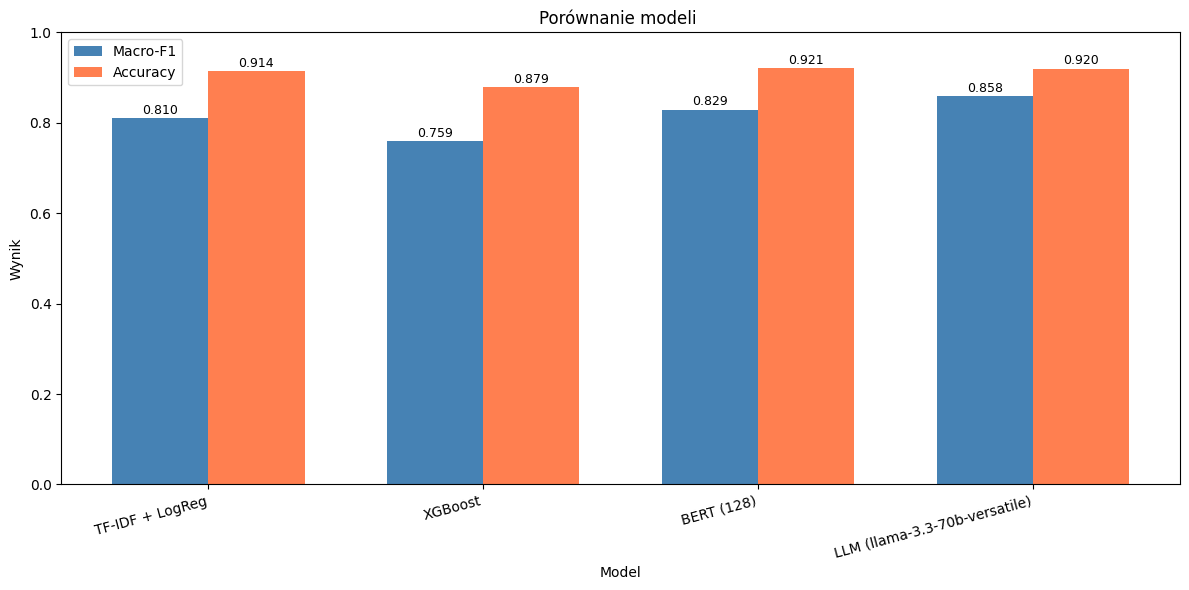

In [ ]:
fig, ax = plt.subplots(figsize=(12, 6))

plot_data = results_full.copy()
if y_pred_llm is not None:
    llm_res = results_llm_subset[-1]
    plot_data.append(llm_res)

models = [r["model"] for r in plot_data]
f1_scores = [r["macro_f1"] for r in plot_data]
accuracies = [r["accuracy"] for r in plot_data]

x = np.arange(len(models))
width = 0.35

bars1 = ax.bar(x - width/2, f1_scores, width, label='Macro-F1', color='steelblue')
bars2 = ax.bar(x + width/2, accuracies, width, label='Accuracy', color='coral')

ax.set_xlabel('Model')
ax.set_ylabel('Wynik')
ax.set_title('Porównanie modeli ')
ax.set_xticks(x)
ax.set_xticklabels(models, rotation=15, ha='right')
ax.legend()
ax.set_ylim(0, 1)

def add_labels(bars):
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.3f}', xy=(bar.get_x() + bar.get_width()/2, height),
                    xytext=(0, 3), textcoords="offset points", ha='center', fontsize=9)

add_labels(bars1)
add_labels(bars2)

plt.tight_layout()
plt.savefig(REPORTS_DIR / "model_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

## 6. Macierze Pomyłek (Confusion Matrices)

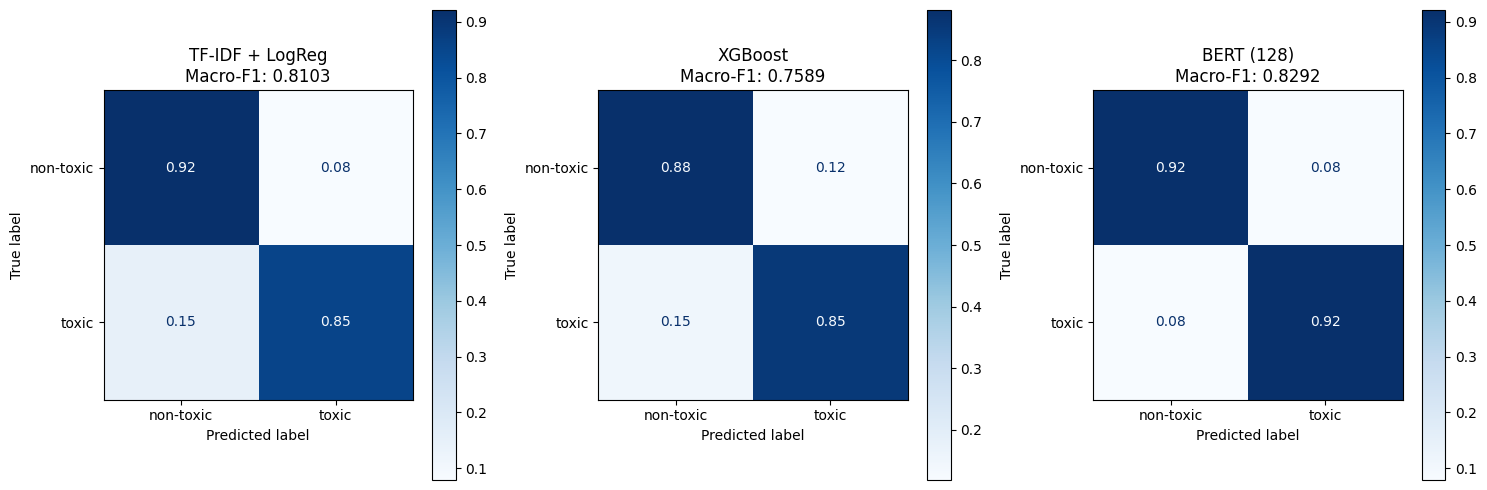

In [ ]:
n_models = len(results_full)
fig, axes = plt.subplots(1, n_models, figsize=(5*n_models, 5))

if n_models == 1:
    axes = [axes]

for ax, r in zip(axes, results_full):
    cm = confusion_matrix(y_test, r["predictions"], normalize='true')
    disp = ConfusionMatrixDisplay(cm, display_labels=CLASS_NAMES)
    disp.plot(ax=ax, cmap="Blues", values_format=".2f")
    ax.set_title(f"{r['model']}\nMacro-F1: {r['macro_f1']:.4f}")

plt.tight_layout()
plt.savefig(REPORTS_DIR / "confusion_matrices.png", dpi=150, bbox_inches="tight")
plt.show()

## 7. Analiza Błędów

In [ ]:
errors = []

for i, (text, true_label) in enumerate(zip(X_test, y_test)):
    preds = {
        "Baseline": int(y_pred_baseline[i]),
        "XGBoost": int(y_pred_xgb[i]),
        "BERT": int(y_pred_bert[i]),
    }

    if y_pred_llm is not None and i < len(y_pred_llm):
        preds["LLM"] = int(y_pred_llm[i])

    wrong_count = sum(1 for p in preds.values() if p != true_label)

    if wrong_count > 0:
        errors.append({
            "index": i,
            "text": text[:300] + "..." if len(text) > 300 else text,
            "true_label": int(true_label),
            "true_class": CLASS_NAMES[true_label],
            "predictions": preds,
            "wrong_count": wrong_count
        })

errors_sorted = sorted(errors, key=lambda x: -x["wrong_count"])

print(f"Razem błędnych klasyfikacji (wśród analizowanych): {len(errors)}")
print(f"\nNajbardziej mylące przypadki:")

Razem błędnych klasyfikacji (wśród analizowanych): 899

Najbardziej mylące przypadki:


In [ ]:
error_analysis = []

for j, err in enumerate(errors_sorted[:10]):
    print(f"Przypadek {j+1}: Prawda = {err['true_class']} ({err['true_label']})")
    print(f"Predykcje: {err['predictions']}")
    print(f"Błędnych modeli: {err['wrong_count']}")
    print(f"Tekst: {err['text']}")

    error_analysis.append({
        "case": j+1,
        "true_label": err['true_class'],
        "predictions": str(err['predictions']),
        "text_preview": err['text'][:100] + "...",
        "analysis": ""
    })

df_errors = pd.DataFrame(error_analysis)
df_errors.to_csv(REPORTS_DIR / "error_analysis.csv", index=False)
print(f"\n\nZapisano analizę błędów do {REPORTS_DIR / 'error_analysis.csv'}")


Przypadek 1: Prawda = non-toxic (0)
Predykcje: {'Baseline': 1, 'XGBoost': 0, 'BERT': 1, 'LLM': 1}
Błędnych modeli: 3
Tekst: since ask yes gone brit millah incidentally know partition muslims pakistan fishing hindus raiding villages asking men drop pants dhotis checking see circumcised pass instant beheading pakistani jews managed get away coz also circumcised thus mistaken muslims muslims thus managed make india across b...

Przypadek 2: Prawda = non-toxic (0)
Predykcje: {'Baseline': 1, 'XGBoost': 1, 'BERT': 0, 'LLM': 1}
Błędnych modeli: 3
Tekst: really interested eisfbnore irretrievably lost respect far back facts actions zealotry speak btw tnx elegant admission puny collusion involved using combined revert quotas order user blocked breaking rr didnt really see way spur moment cynicism thing youre convincing yr description never liked read ...

Przypadek 3: Prawda = toxic (1)
Predykcje: {'Baseline': 0, 'XGBoost': 0, 'BERT': 0, 'LLM': 1}
Błędnych modeli: 3
Tekst: think know better adm

## 8. Zapis Wyników Końcowych

In [ ]:
final_results = {
    "task": "Binary toxicity classification",
    "dataset": "Jigsaw Toxic Comment (Wikipedia)",
    "test_sample_size": len(y_test),
    "seed": SEED,
    "class_names": CLASS_NAMES,
    "models_full_test": [{
        "name": r["model"],
        "accuracy": float(r["accuracy"]),
        "macro_f1": float(r["macro_f1"]),
        "roc_auc": float(r["roc_auc"]) if r["roc_auc"] else None
    } for r in results_full],
    "models_llm_subset": [{
        "name": r["model"],
        "accuracy": float(r["accuracy"]),
        "macro_f1": float(r["macro_f1"]),
        "roc_auc": float(r["roc_auc"]) if r["roc_auc"] else None
    } for r in results_llm_subset]
}

with open(REPORTS_DIR / "final_results.json", "w") as f:
    json.dump(final_results, f, indent=2)

print(f"Zapisano końcowe wyniki do {REPORTS_DIR / 'final_results.json'}")

Zapisano końcowe wyniki do ../reports/final_results.json


In [ ]:
print(f"Rozmiar próbki testowej: {len(y_test)}")
print(f"Rozkład klas: 0={sum(y_test==0)}, 1={sum(y_test==1)}, 2={sum(y_test==2)}")
print("\nWyniki (sortowane po Macro-F1):")
for r in sorted(results_full, key=lambda x: -x['macro_f1']):
    auc_str = f", AUC={r['roc_auc']:.4f}" if r['roc_auc'] else ""
    print(f"  {r['model']:25s} Acc={r['accuracy']:.4f}, F1={r['macro_f1']:.4f}{auc_str}")

if results_llm_subset:
    print("\nWyniki na podzbiorze LLM (sortowane po Macro-F1):")
    for r in sorted(results_llm_subset, key=lambda x: -x['macro_f1']):
        auc_str = f", AUC={r['roc_auc']:.4f}" if r['roc_auc'] else ""
        print(f"  {r['model']:25s} Acc={r['accuracy']:.4f}, F1={r['macro_f1']:.4f}{auc_str}")

print("\nZapisane pliki:")
print(f"  - {REPORTS_DIR / 'model_comparison.png'}")
print(f"  - {REPORTS_DIR / 'confusion_matrices.png'}")
print(f"  - {REPORTS_DIR / 'error_analysis.csv'}")
print(f"  - {REPORTS_DIR / 'final_results.json'}")